In [26]:
import tensorflow as tf

In [27]:
tf.__version__

'2.17.0'

In [28]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Input, Conv2D, Dense, Flatten, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.datasets import fashion_mnist

In [29]:
#carregando o dataset e normalizando os dados

(X_treinamento, y_treinamento), (X_teste, y_teste) = fashion_mnist.load_data()
X_treinamento, X_teste = X_treinamento / 255, X_teste / 255
print(X_treinamento.shape)

(60000, 28, 28)


In [30]:
#adicionando a dimensão faltante

X_treinamento = np.expand_dims(X_treinamento, -1)
X_teste = np.expand_dims(X_teste, -1)
print(X_treinamento.shape)

(60000, 28, 28, 1)


In [31]:
#número de classes

len(np.unique(y_treinamento))

10

In [33]:
#criando a rede neural através da API funcional

i = Input(shape=X_treinamento[0].shape)
x = Conv2D(32, (3,3), strides=2, activation='relu')(i)
x = Conv2D(64, (3,3), strides=2, activation='relu')(x)
x = Conv2D(128, (3,3), strides=2, activation='relu')(x)
x = Flatten()(x)
x = Dropout(0.2)(x)
x = Dense(512, activation='relu')(x)
x = Dropout(0.2)(x)
x = Dense(10, activation='softmax')(x)

model = Model(i,x)

In [34]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
r = model.fit(X_treinamento, y_treinamento, validation_data=(X_teste, y_teste), epochs=10)

Epoch 1/10


I0000 00:00:1724091911.963054   13277 service.cc:146] XLA service 0x795468003bc0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1724091911.963079   13277 service.cc:154]   StreamExecutor device (0): NVIDIA GeForce RTX 3050 Laptop GPU, Compute Capability 8.6
2024-08-19 15:25:11.995373: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2024-08-19 15:25:12.142451: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:531] Loaded cuDNN version 8907


  87/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.4519 - loss: 1.5838

I0000 00:00:1724091914.474306   13277 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.7481 - loss: 0.6980 - val_accuracy: 0.8515 - val_loss: 0.3964
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8609 - loss: 0.3718 - val_accuracy: 0.8642 - val_loss: 0.3572
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8807 - loss: 0.3158 - val_accuracy: 0.8827 - val_loss: 0.3103
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8966 - loss: 0.2751 - val_accuracy: 0.8790 - val_loss: 0.3208
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9060 - loss: 0.2484 - val_accuracy: 0.8923 - val_loss: 0.2939
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9128 - loss: 0.2288 - val_accuracy: 0.8954 - val_loss: 0.2981
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9208 - loss: 0.2080 - val_accuracy: 0.8933 - val_loss: 0.3053
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9261 - loss: 0.1942 - val_accurac

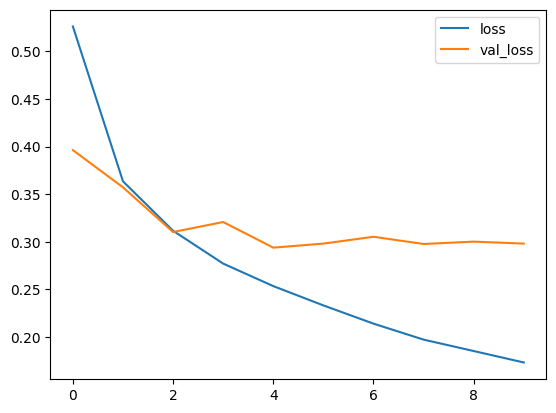

In [37]:
#plotando a loss por iteração

plt.plot(r.history['loss'], label='loss')
plt.plot(r.history['val_loss'], label='val_loss')
plt.legend()

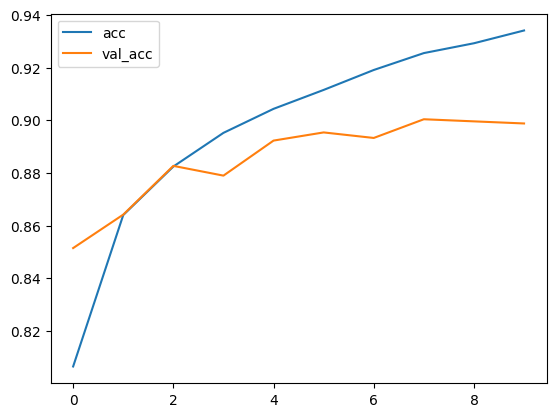

In [38]:
#plotando a acurácia por iteração

plt.plot(r.history['accuracy'], label='acc')
plt.plot(r.history['val_accuracy'], label='val_acc')
plt.legend()

In [40]:
#função para plotar a matriz de confusão com gráfico

from sklearn.metrics import confusion_matrix
import itertools

def plot_confusion_matrix(cm, classes, 
                          normalize=False, 
                          title='Confusion Matrix',
                          cmap=plt.cm.Blues):
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion Matrix')

    print(cm)

    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment='center',
                 color='white' if cm[i,j] > thresh else 'black')
        
    plt.tight_layout()
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
Confusion Matrix
[[883   0  16  17   2   0  76   0   6   0]
 [  2 974   1  12   2   0   7   0   2   0]
 [ 22   0 848   8  35   0  86   0   1   0]
 [ 13   8  18 896  29   0  35   0   1   0]
 [  0   1  94  20 795   0  87   0   3   0]
 [  1   1   0   0   0 976   0  14   3   5]
 [129   0  50  21  71   1 721   0   7   0]
 [  0   0   0   0   0  11   0 958   1  30]
 [  2   0   3   4   4   1   6   1 979   0]
 [  1   0   0   0   0   7   0  34   0 958]]


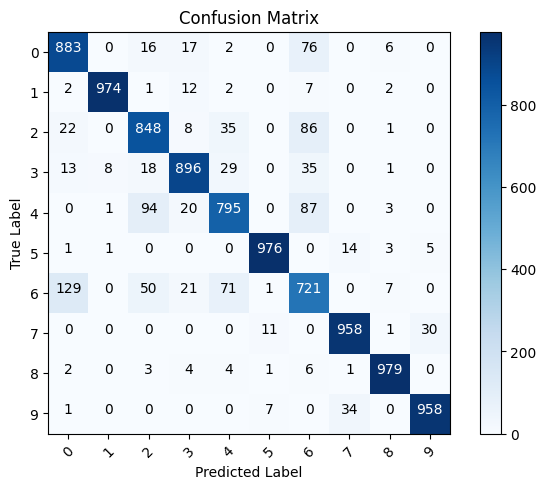

In [41]:
#plotando a matriz de confusão

p_teste = model.predict(X_teste).argmax(axis=1)
cm = confusion_matrix(y_teste, p_teste)
plot_confusion_matrix(cm, list(range(10)))